<a href="https://colab.research.google.com/github/geopayme/AstroPhysics/blob/main/QITFT_Module5_Propagators_Animated_Fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📘 Momentum-Space Propagator D(p):


Eq(D(p0, p1, p2, p3), -I/(m**2 - p0**2 + p1**2 + p2**2 + p3**2 - 1.0e-6*I))

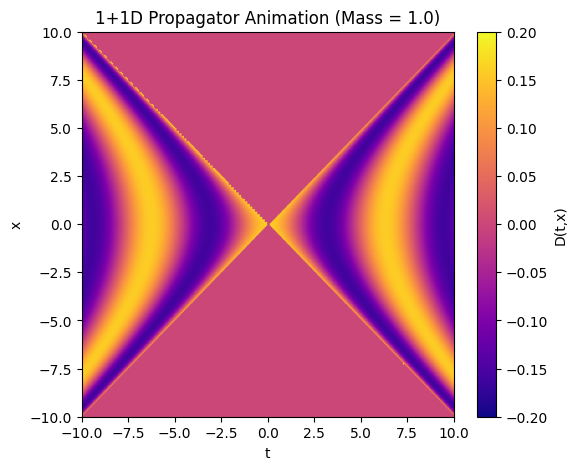


📘 ∞-Tensor 3-Field Interaction Vertex:


Eq(V3(psi1, psi2, psi3), lambda_3*psi1*psi2*psi3)

In [1]:

# 📘 QITFT — Module 5: ∞-Tensor Propagators & Interaction Diagrams (Animated + Fixed)

!pip install sympy matplotlib numpy --quiet

from sympy import symbols, Function, I, exp, pi, simplify, Eq, DiracDelta
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import warnings
from matplotlib.animation import FuncAnimation

# ------------------------------------------------------------
# 📡 Propagator in Momentum Space for Scalar Field
# ------------------------------------------------------------

# Define symbols
p0, p1, p2, p3, m = symbols('p0 p1 p2 p3 m')
p_sq = p0**2 - p1**2 - p2**2 - p3**2
D_p = I / (p_sq - m**2 + I * 1e-6)

print("📘 Momentum-Space Propagator D(p):")
display(Eq(Function('D')(p0, p1, p2, p3), simplify(D_p)))

# ------------------------------------------------------------
# 🧭 1+1D Configuration Space Propagator (Animated)
# ------------------------------------------------------------

# Fix invalid sqrt warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Grid setup
t_vals = np.linspace(-10, 10, 300)
x_vals = np.linspace(-10, 10, 300)
T, X = np.meshgrid(t_vals, x_vals)
M = 1.0

def propagator_1D(t, x, m=M):
    r_sq = t**2 - x**2
    return np.where(r_sq > 0, 1/(2 * np.pi) * np.cos(m * np.sqrt(r_sq)), 0)

# Initial frame
Z = propagator_1D(T, X)

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.imshow(Z, extent=[-10, 10, -10, 10], origin='lower', cmap='plasma', aspect='auto', vmin=-0.2, vmax=0.2)
fig.colorbar(cax, label='D(t,x)')
ax.set_xlabel("t")
ax.set_ylabel("x")
ax.set_title("1+1D Propagator Animation (Mass = 1.0)")

def update(frame):
    mass = 0.5 + frame * 0.05
    Z_new = propagator_1D(T, X, m=mass)
    cax.set_data(Z_new)
    ax.set_title(f"1+1D Propagator: Mass = {mass:.2f}")
    return [cax]

ani = FuncAnimation(fig, update, frames=30, interval=200, blit=False)
plt.show()

# ------------------------------------------------------------
# ✳️ ∞-Tensor Interaction Vertex Diagram (Symbolic)
# ------------------------------------------------------------

psi1, psi2, psi3 = symbols('psi1 psi2 psi3')
lambda_3 = symbols('lambda_3')

vertex_expr = lambda_3 * psi1 * psi2 * psi3

print("\n📘 ∞-Tensor 3-Field Interaction Vertex:")
display(Eq(Function('V3')(psi1, psi2, psi3), vertex_expr))
